<a href="https://colab.research.google.com/github/devmurarijay13/pytorch-deep-learning/blob/main/loan_approval_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
pip install torchinfo

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader

In [ ]:
df = pd.read_csv('loan_data.csv')

In [ ]:
df.shape

(45000, 14)

In [ ]:
df.sample(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
17194,23.0,female,High School,121228.0,1,MORTGAGE,14000.0,DEBTCONSOLIDATION,6.17,0.12,4.0,657,No,0
1382,22.0,male,High School,44480.0,0,RENT,1000.0,PERSONAL,7.68,0.02,4.0,658,No,0
29534,36.0,male,High School,63904.0,11,RENT,2250.0,HOMEIMPROVEMENT,5.42,0.04,14.0,628,Yes,0
5236,21.0,female,Bachelor,54464.0,2,OWN,5000.0,EDUCATION,13.87,0.09,3.0,663,Yes,0
5481,21.0,male,High School,55080.0,0,MORTGAGE,10000.0,PERSONAL,7.51,0.18,2.0,652,Yes,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


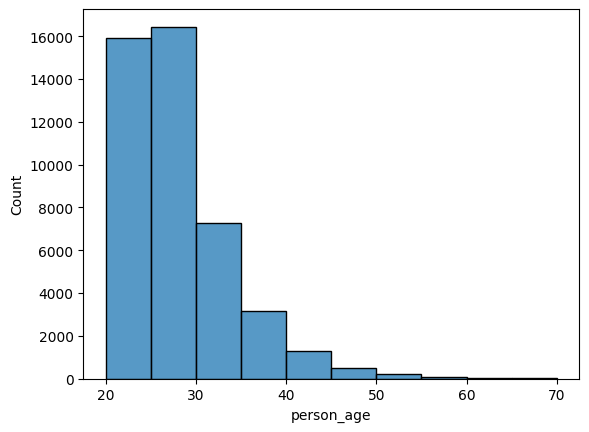

In [ ]:
sns.histplot(df['person_age'],bins=[20,25,30,35,40,45,50,55,60,65,70])
plt.show()

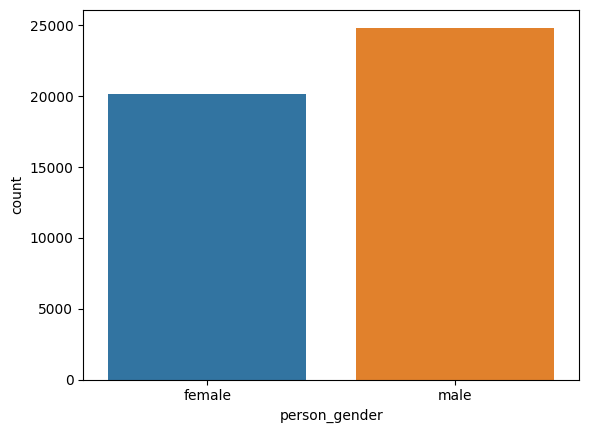

In [ ]:
sns.countplot(x=df['person_gender'],hue=df['person_gender'])
plt.show()

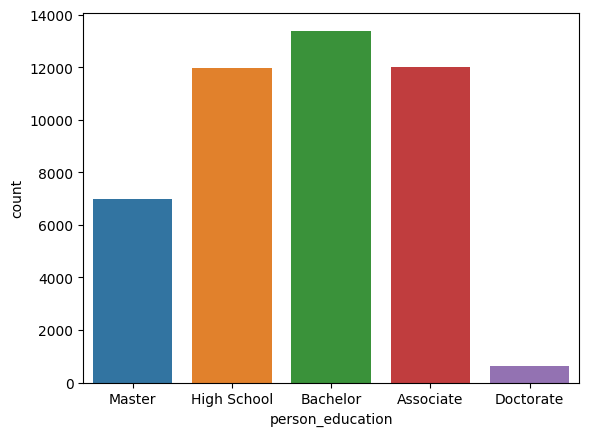

In [ ]:
sns.countplot(data=df,x='person_education',hue='person_education')
plt.show()

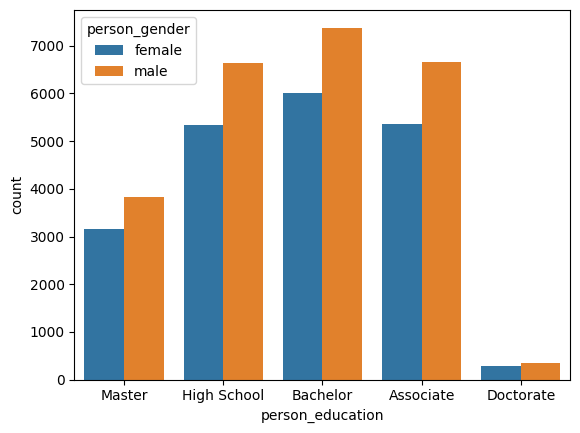

In [ ]:
sns.countplot(data=df,x='person_education',hue='person_gender')
plt.show()

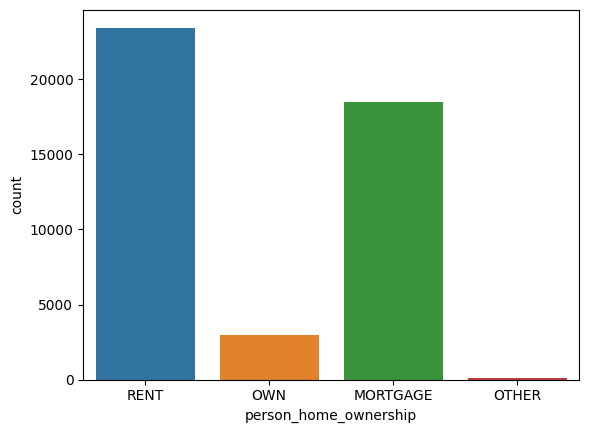

In [ ]:
sns.countplot(data=df,x='person_home_ownership',hue='person_home_ownership')
plt.show()

In [ ]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns.to_list()
numerical_cols = X.select_dtypes(exclude='object').columns.to_list()

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
encoder = LabelEncoder()
scaler = StandardScaler()

In [ ]:
for col in categorical_cols:
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [131]:
X_train_tensor = torch.from_numpy(X_train)
X_test_tensor = torch.from_numpy(X_test)
y_train_tensor = torch.from_numpy(y_train.values).float().view(-1,1)
y_test_tensor = torch.from_numpy(y_test.values).float().view(-1,1)

In [132]:
class CustomDataset(Dataset):

    def __init__(self,features,labels):

        self.features = torch.tensor(features,dtype=torch.float32)
        self.labels = torch.tensor(labels,dtype=torch.float32)

    def __len__(self):

        return len(self.features)

    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [133]:
train_dataset = CustomDataset(X_train_tensor,y_train_tensor)
test_dataset = CustomDataset(X_test_tensor,y_test_tensor)

/tmp/ipykernel_1079/3615780293.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.features = torch.tensor(features,dtype=torch.float32)
/tmp/ipykernel_1079/3615780293.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels,dtype=torch.float32)


In [134]:
train_loader = DataLoader(train_dataset,batch_size=512,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=512,shuffle=False)

In [193]:
class NeuralNetwork(nn.Module):

    def __init__(self,n_dim):

        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(n_dim,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [194]:
model = NeuralNetwork(X_train_tensor.shape[1])

In [195]:
summary(model)

Layer (type:depth-idx)                   Param #
NeuralNetwork                            --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       896
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       2,080
│    └─ReLU: 2-4                         --
│    └─Linear: 2-5                       528
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       17
│    └─Sigmoid: 2-8                      --
Total params: 3,521
Trainable params: 3,521
Non-trainable params: 0

In [198]:
learning_rate = 0.01
epochs = 50

In [199]:
optimizer = optim.Adam(model.parameters(),lr=learning_rate)
criterion = nn.BCELoss()

In [200]:
##### training pipeline
for epoch in range(epochs):

    model.train()

    total_epoch_loss = 0

    for batch_features,batch_labels in train_loader:

        #### forward pass
        y_pred = model(batch_features)

        #### loss calculation
        loss = criterion(y_pred,batch_labels)

        #### clear gradients
        optimizer.zero_grad()

        #### backward pass
        loss.backward()

        #### weight updation
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} ==> Loss {avg_loss:.4f}")

Epoch 1/50 ==> Loss 0.2965
Epoch 2/50 ==> Loss 0.2167
Epoch 3/50 ==> Loss 0.2086
Epoch 4/50 ==> Loss 0.2035
Epoch 5/50 ==> Loss 0.2013
Epoch 6/50 ==> Loss 0.1946
Epoch 7/50 ==> Loss 0.1946
Epoch 8/50 ==> Loss 0.1909
Epoch 9/50 ==> Loss 0.1897
Epoch 10/50 ==> Loss 0.1873
Epoch 11/50 ==> Loss 0.1868
Epoch 12/50 ==> Loss 0.1844
Epoch 13/50 ==> Loss 0.1829
Epoch 14/50 ==> Loss 0.1824
Epoch 15/50 ==> Loss 0.1825
Epoch 16/50 ==> Loss 0.1793
Epoch 17/50 ==> Loss 0.1781
Epoch 18/50 ==> Loss 0.1770
Epoch 19/50 ==> Loss 0.1794
Epoch 20/50 ==> Loss 0.1744
Epoch 21/50 ==> Loss 0.1773
Epoch 22/50 ==> Loss 0.1751
Epoch 23/50 ==> Loss 0.1739
Epoch 24/50 ==> Loss 0.1721
Epoch 25/50 ==> Loss 0.1708
Epoch 26/50 ==> Loss 0.1704
Epoch 27/50 ==> Loss 0.1707
Epoch 28/50 ==> Loss 0.1714
Epoch 29/50 ==> Loss 0.1691
Epoch 30/50 ==> Loss 0.1677
Epoch 31/50 ==> Loss 0.1689
Epoch 32/50 ==> Loss 0.1665
Epoch 33/50 ==> Loss 0.1657
Epoch 34/50 ==> Loss 0.1639
Epoch 35/50 ==> Loss 0.1650
Epoch 36/50 ==> Loss 0.1629
E

In [201]:
model.eval()

NeuralNetwork(
  (model): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

In [208]:
with torch.inference_mode():

    for batch_features,batch_labels in test_loader:

        test_pred = model(batch_features)
        test_pred = (test_pred>0.6).float()

        test_loss = criterion(test_pred,batch_labels)

    print(f"accuracy : {accuracy_score(test_pred,batch_labels)}")
    print(f'confusion matrix :\n {confusion_matrix(test_pred,batch_labels)}')
    print(f"classification matrix : \n {classification_report(test_pred,batch_labels)}")

accuracy : 0.9087837837837838
confusion matrix :
 [[228  22]
 [  5  41]]
classification matrix : 
               precision    recall  f1-score   support

         0.0       0.98      0.91      0.94       250
         1.0       0.65      0.89      0.75        46

    accuracy                           0.91       296
   macro avg       0.81      0.90      0.85       296
weighted avg       0.93      0.91      0.91       296

